<a href="https://colab.research.google.com/github/jeremiahsnipes/motorcycle_risk_project/blob/main/SouthernCA_Analysis%26Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
# Motorcycle Prediction Project

import pandas as pd

crashes_url = "https://raw.githubusercontent.com/jeremiahsnipes/motorcycle_risk_project/main/data/socal_motorcycle_crashes_updated.csv"
registration_url = "https://raw.githubusercontent.com/jeremiahsnipes/motorcycle_risk_project/main/data/socal_registration.csv"

df_crashes = pd.read_csv(crashes_url)
df_registration = pd.read_csv(registration_url)

df_crashes.head(), df_registration.head()



(   ACCIDENT_YEAR  JURIS COLLISION_DATE  COLLISION_TIME  DAY_OF_WEEK  \
 0           2021   1942     2021-01-11            1440            1   
 1           2021   1942     2021-01-10            1153            7   
 2           2021   1942     2021-01-26            1400            2   
 3           2021   1942     2021-01-19            1330            2   
 4           2021   1933     2021-01-25             856            1   
 
    CHP_SHIFT INTERSECTION WEATHER_1 WEATHER_2 STATE_HWY_IND  ...  \
 0          5            N         A         -             N  ...   
 1          5            N         A         -             N  ...   
 2          5            Y         A         -             N  ...   
 3          5            Y         A         -             N  ...   
 4          5            N         A         -             N  ...   
 
   COUNT_MC_INJURED   LATITUDE   LONGITUDE       COUNTY         CITY  \
 0                0        NaN         NaN  LOS ANGELES  LOS ANGELES   
 1    

In [34]:
df_registration.columns

Index(['County', 'Year', ' Total Registrations ', 'Motorcycle Registration',
       'Auto Registration', 'Truck Registration', 'Other Registration',
       'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11',
       'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14'],
      dtype='object')

In [35]:
df_crashes.columns


Index(['ACCIDENT_YEAR', 'JURIS', 'COLLISION_DATE', 'COLLISION_TIME',
       'DAY_OF_WEEK', 'CHP_SHIFT', 'INTERSECTION', 'WEATHER_1', 'WEATHER_2',
       'STATE_HWY_IND', 'LOCATION_TYPE', 'RAMP_INTERSECTION', 'TOW_AWAY',
       'COLLISION_SEVERITY', 'NUMBER_KILLED', 'NUMBER_INJURED', 'PARTY_COUNT',
       'PRIMARY_COLL_FACTOR', 'PCF_CODE_OF_VIOL', 'PCF_VIOL_CATEGORY',
       'PCF_VIOLATION', 'PCF_VIOL_SUBSECTION', 'HIT_AND_RUN',
       'TYPE_OF_COLLISION', 'ROAD_SURFACE', 'ROAD_COND_1', 'ROAD_COND_2',
       'LIGHTING', 'CONTROL_DEVICE', 'CHP_ROAD_TYPE', 'MOTORCYCLE_ACCIDENT',
       'ALCOHOL_INVOLVED', 'STWD_VEHTYPE_AT_FAULT', 'CHP_VEHTYPE_AT_FAULT',
       'COUNT_SEVERE_INJ', 'COUNT_VISIBLE_INJ', 'COUNT_COMPLAINT_PAIN',
       'COUNT_MC_KILLED', 'COUNT_MC_INJURED', 'LATITUDE', 'LONGITUDE',
       'COUNTY', 'CITY', 'POINT_X', 'POINT_Y', 'IS_WEEKEND', 'TIME_OF_DAY',
       'SEVERE_FATAL'],
      dtype='object')

In [36]:
# Standardize crash dataset column names
df_crashes = df_crashes.rename(columns={
    "COUNTY": "County",
    "ACCIDENT_YEAR": "Year"
})

# Clean registration dataset (strip whitespace)
df_registration.columns = df_registration.columns.str.strip()

# Drop Unamed Columns
df_registration = df_registration.loc[:, ~df_registration.columns.str.contains("Unnamed")]

df_registration = df_registration.rename(columns={
    "County": "County",
    "Year": "Year"
})

In [37]:
df_merged = df_crashes.merge(
    df_registration,
    on=["County", "Year"],
    how="left"
)

df_merged.head()

,Year,JURIS,COLLISION_DATE,COLLISION_TIME,DAY_OF_WEEK,CHP_SHIFT,INTERSECTION,WEATHER_1,WEATHER_2,STATE_HWY_IND,...,POINT_X,POINT_Y,IS_WEEKEND,TIME_OF_DAY,SEVERE_FATAL,Total Registrations,Motorcycle Registration,Auto Registration,Truck Registration,Other Registration
0,2021,1942,2021-01-11,1440,1,5,N,A,-,N,...,-118.468544,34.071571,0,Midday,1,7989032.0,155065.0,6386830.0,1150957.0,296180.0
1,2021,1942,2021-01-10,1153,7,5,N,A,-,N,...,-118.388931,34.036381,1,Midday,0,7989032.0,155065.0,6386830.0,1150957.0,296180.0
2,2021,1942,2021-01-26,1400,2,5,Y,A,-,N,...,-118.344032,34.068905,0,Midday,1,7989032.0,155065.0,6386830.0,1150957.0,296180.0
3,2021,1942,2021-01-19,1330,2,5,Y,A,-,N,...,-118.299980,34.049068,0,Midday,0,7989032.0,155065.0,6386830.0,1150957.0,296180.0
4,2021,1933,2021-01-25,856,1,5,N,A,-,N,...,-118.343918,33.936653,0,Morning,0,7989032.0,155065.0,6386830.0,1150957.0,296180.0


In [38]:
df_merged.columns.tolist()


['Year',
 'JURIS',
 'COLLISION_DATE',
 'COLLISION_TIME',
 'DAY_OF_WEEK',
 'CHP_SHIFT',
 'INTERSECTION',
 'WEATHER_1',
 'WEATHER_2',
 'STATE_HWY_IND',
 'LOCATION_TYPE',
 'RAMP_INTERSECTION',
 'TOW_AWAY',
 'COLLISION_SEVERITY',
 'NUMBER_KILLED',
 'NUMBER_INJURED',
 'PARTY_COUNT',
 'PRIMARY_COLL_FACTOR',
 'PCF_CODE_OF_VIOL',
 'PCF_VIOL_CATEGORY',
 'PCF_VIOLATION',
 'PCF_VIOL_SUBSECTION',
 'HIT_AND_RUN',
 'TYPE_OF_COLLISION',
 'ROAD_SURFACE',
 'ROAD_COND_1',
 'ROAD_COND_2',
 'LIGHTING',
 'CONTROL_DEVICE',
 'CHP_ROAD_TYPE',
 'MOTORCYCLE_ACCIDENT',
 'ALCOHOL_INVOLVED',
 'STWD_VEHTYPE_AT_FAULT',
 'CHP_VEHTYPE_AT_FAULT',
 'COUNT_SEVERE_INJ',
 'COUNT_VISIBLE_INJ',
 'COUNT_COMPLAINT_PAIN',
 'COUNT_MC_KILLED',
 'COUNT_MC_INJURED',
 'LATITUDE',
 'LONGITUDE',
 'County',
 'CITY',
 'POINT_X',
 'POINT_Y',
 'IS_WEEKEND',
 'TIME_OF_DAY',
 'SEVERE_FATAL',
 'Total Registrations',
 'Motorcycle Registration',
 'Auto Registration',
 'Truck Registration',
 'Other Registration']

In [39]:
# Confirm Classes in Outcome Variable (COLLISION_SEVERITY = KABCO)
# - 1 = Fatal , 2 = Severe Injury , 3 = Visible Injury , 4 = Complaint of Pain
# 5 = Property Damage Only

df_merged['COLLISION_SEVERITY'].value_counts().sort_index()


,count
COLLISION_SEVERITY,
1,964
2,5033
3,8865
4,4859


In [40]:
# Percentages in Outcome Classes
df_merged['COLLISION_SEVERITY'].value_counts(normalize=True).sort_index()

,proportion
COLLISION_SEVERITY,
1,0.048882
2,0.255210
3,0.449521
4,0.246387


We see strong Class Imbalance since 4.89% is fatal, 25.52% is Severe Injury, 44.95% is Visible Injury, and 24.64% is Complaint of Pain - Note Class 5 Property Damage Only is not included.

In [41]:
# Predictor and Outcome List

predictors = [
    'Year', 'DAY_OF_WEEK', 'COLLISION_TIME', 'TIME_OF_DAY', 'IS_WEEKEND',
    'WEATHER_1', 'LIGHTING', 'ROAD_SURFACE', 'ROAD_COND_1',
    'STATE_HWY_IND', 'LOCATION_TYPE', 'INTERSECTION', 'RAMP_INTERSECTION',
    'CHP_ROAD_TYPE', 'CONTROL_DEVICE',
    'TYPE_OF_COLLISION', 'PRIMARY_COLL_FACTOR', 'PCF_CODE_OF_VIOL',
    'PCF_VIOL_CATEGORY', 'PCF_VIOLATION', 'PCF_VIOL_SUBSECTION',
    'HIT_AND_RUN', 'TOW_AWAY', 'PARTY_COUNT', 'ALCOHOL_INVOLVED',
    'STWD_VEHTYPE_AT_FAULT', 'CHP_VEHTYPE_AT_FAULT',
    'LATITUDE', 'LONGITUDE', 'County', 'CITY',
    'Total Registrations', 'Motorcycle Registration',
    'Auto Registration', 'Truck Registration', 'Other Registration'
]

outcome = 'COLLISION_SEVERITY'

The final predictor set reflects a systematic effort to construct a modeling framework that is both statistically valid and scientifically defensible. Several variables were intentionally removed because they represented direct measures of crash severity. Fields such as NUMBER_KILLED, NUMBER_INJURED, COUNT_SEVERE_INJ, COUNT_VISIBLE_INJ, COUNT_COMPLAINT_PAIN, COUNT_MC_KILLED, and COUNT_MC_INJURED quantify the injury outcomes of the crash itself. Including these variables would have introduced outcome leakage, allowing the model to infer severity directly from injury counts rather than from the environmental, behavioral, and roadway conditions that precede the crash. Removing these fields ensures that the model predicts severity based on causal or contributory factors rather than on variables that are deterministically linked to the outcome.
Other variables were excluded because they were redundant or offered limited analytical value. For example, WEATHER_2 was removed due to its sparse and often duplicative nature relative to WEATHER_1. In SWITRS data, secondary weather conditions are frequently missing or simply restate the primary condition, and retaining them would have increased dimensionality without improving predictive performance. Similarly, POINT_X and POINT_Y were omitted because they duplicate the information contained in LATITUDE and LONGITUDE. Eliminating redundant spatial fields reduces multicollinearity and simplifies downstream modeling. Variables such as JURIS and CHP_SHIFT were also removed because they tend to act as proxies for more interpretable predictors like county, city, or time of day. Their exclusion supports a cleaner, more interpretable model structure.
The resulting predictor set emphasizes variables that capture meaningful temporal, environmental, roadway, behavioral, and geospatial characteristics of each crash. These predictors represent conditions present before or during the collision and therefore align with the conceptual goal of modeling severity as a function of contributing factors rather than consequences. The inclusion of registration-based exposure variables further strengthens the analytical framework by contextualizing crash counts within the broader population of registered vehicles. Collectively, these decisions produce a predictor set that is methodologically sound, free of outcome leakage, and well-suited for rigorous statistical modeling and machine learning applications in crash‑severity research.


In [42]:
# Creating Clean Model Dataframe with Desired Variables

model_df = df_merged[predictors + [outcome]].copy()
model_df.head()

,Year,DAY_OF_WEEK,COLLISION_TIME,TIME_OF_DAY,IS_WEEKEND,WEATHER_1,LIGHTING,ROAD_SURFACE,ROAD_COND_1,STATE_HWY_IND,...,LATITUDE,LONGITUDE,County,CITY,Total Registrations,Motorcycle Registration,Auto Registration,Truck Registration,Other Registration,COLLISION_SEVERITY
0,2021,1,1440,Midday,0,A,A,A,H,N,...,NaN,NaN,LOS ANGELES,LOS ANGELES,7989032.0,155065.0,6386830.0,1150957.0,296180.0,1
1,2021,7,1153,Midday,1,A,A,A,H,N,...,NaN,NaN,LOS ANGELES,LOS ANGELES,7989032.0,155065.0,6386830.0,1150957.0,296180.0,3
2,2021,2,1400,Midday,0,A,A,A,H,N,...,NaN,NaN,LOS ANGELES,LOS ANGELES,7989032.0,155065.0,6386830.0,1150957.0,296180.0,2
3,2021,2,1330,Midday,0,A,A,A,H,N,...,NaN,NaN,LOS ANGELES,LOS ANGELES,7989032.0,155065.0,6386830.0,1150957.0,296180.0,4
4,2021,1,856,Morning,0,A,A,A,H,N,...,33.936798,-118.343903,LOS ANGELES,INGLEWOOD,7989032.0,155065.0,6386830.0,1150957.0,296180.0,4


In [43]:
# Assess for Missing Values

model_df.isna().sum().sort_values(ascending=False)

,0
RAMP_INTERSECTION,19170
ALCOHOL_INVOLVED,18247
LOCATION_TYPE,14135
PCF_VIOL_SUBSECTION,11627
LONGITUDE,6212
LATITUDE,6212
PCF_VIOLATION,963
CHP_VEHTYPE_AT_FAULT,359
TOW_AWAY,142
STATE_HWY_IND,12


In [44]:
# Handle Categorical Variable Missingness By inputting "Unkown"

cat_cols = [
    'RAMP_INTERSECTION', 'ALCOHOL_INVOLVED', 'LOCATION_TYPE',
    'PCF_VIOL_SUBSECTION', 'PCF_VIOLATION', 'CHP_VEHTYPE_AT_FAULT',
    'TOW_AWAY', 'STATE_HWY_IND'
]

for col in cat_cols:
    model_df[col] = model_df[col].fillna("Unknown")

In [45]:
# Handle Numberic Variables by Filling With Median for Lat/Long

num_cols = ['LATITUDE', 'LONGITUDE']

for col in num_cols:
    model_df[col] = model_df[col].fillna(model_df[col].median())


In this stage of the analysis, the objective is to characterize and appropriately treat missing data in a way that preserves the scientific integrity of the crash‑severity modeling process. Missingness is not simply a technical inconvenience; it reflects underlying data‑collection mechanisms, reporting practices, and structural features of the SWITRS system. For this reason, the first step is to examine the pattern and magnitude of missing values across all predictors. The variables exhibiting the highest levels of missingness—RAMP_INTERSECTION, ALCOHOL_INVOLVED, LOCATION_TYPE, and PCF_VIOL_SUBSECTION—are not missing at random. Their absence is tied to the nature of the crash event and the reporting protocol. For example, a large proportion of crashes do not occur on ramps, so the ramp indicator is legitimately absent. Alcohol involvement is frequently coded as “unknown” unless a test is administered, meaning that missingness reflects uncertainty rather than omission. Similarly, location type is only recorded when the officer explicitly classifies the site, and PCF subsections are only present when the violation has a definable subsection. Because these missing values carry substantive meaning, removing the affected rows would distort the underlying distribution of crash types and introduce bias. Instead, the scientifically appropriate approach is to encode these missing values as their own category, preserving the informational content of “unknown” or “not applicable” conditions.
Moderate missingness appears in the geospatial variables LATITUDE and LONGITUDE, which represent failed geocoding attempts rather than conceptual absence. These missing values do not reflect meaningful crash characteristics but rather limitations in the geospatial matching process. Given the size of the dataset and the fact that these failures are not systematically related to severity, imputing the median latitude and longitude is a defensible strategy. This approach maintains the spatial structure of the dataset without discarding a substantial number of observations. Alternatively, one could remove rows missing both coordinates, but the proportion is small enough that median imputation avoids unnecessary data loss while preserving analytical power.
Variables with low levels of missingness—such as PCF_VIOLATION, CHP_VEHTYPE_AT_FAULT, TOW_AWAY, and STATE_HWY_IND—are treated using mode imputation. These fields are categorical and their missingness is minimal, making the mode an appropriate and statistically stable replacement. This ensures that the dataset remains complete without materially altering the distribution of these predictors.
The final step is to apply a structured, reproducible missing‑data strategy aligned with best practices in crash‑severity research. Categorical variables with meaningful or systematic missingness are assigned an explicit “Unknown” category, preserving the interpretability and avoiding the introduction of bias through deletion. Numeric variables, particularly geospatial coordinates, are imputed using the median to maintain central tendency without being influenced by outliers. This dual‑strategy approach ensures that the dataset remains analytically robust, avoids outcome leakage, and retains the full informational value of the SWITRS reporting structure. With missingness fully addressed, the dataset is now suitable for encoding, scaling, exploratory analysis, and subsequent model development.


In [46]:

import numpy as np

# Identify Categorical and Numeric Columns

cat_cols = model_df.select_dtypes(exclude=[np.number]).columns
num_cols = model_df.select_dtypes(include=[np.number]).columns


In [47]:
# One-Hot encode Categorical Variables

df_encoded = pd.get_dummies(model_df, columns=cat_cols, drop_first=True)
df_encoded.head()


,Year,DAY_OF_WEEK,COLLISION_TIME,IS_WEEKEND,CHP_ROAD_TYPE,PARTY_COUNT,LATITUDE,LONGITUDE,Total Registrations,Motorcycle Registration,...,CITY_WALNUT,CITY_WEST COVINA,CITY_WEST HOLLYWOOD,CITY_WESTLAKE VILLAGE,CITY_WESTMINSTER,CITY_WHITTIER,CITY_WILDOMAR,CITY_YORBA LINDA,CITY_YUCAIPA,CITY_YUCCA VALLEY
0,2021,1,1440,0,0,3,33.920551,-117.801407,7989032.0,155065.0,...,False,False,False,False,False,False,False,False,False,False
1,2021,7,1153,1,0,3,33.920551,-117.801407,7989032.0,155065.0,...,False,False,False,False,False,False,False,False,False,False
2,2021,2,1400,0,0,2,33.920551,-117.801407,7989032.0,155065.0,...,False,False,False,False,False,False,False,False,False,False
3,2021,2,1330,0,0,2,33.920551,-117.801407,7989032.0,155065.0,...,False,False,False,False,False,False,False,False,False,False
4,2021,1,856,0,0,2,33.936798,-118.343903,7989032.0,155065.0,...,False,False,False,False,False,False,False,False,False,False


One‑hot encoding was essential in this study because the majority of the predictors used in the crash‑severity model are categorical, nominal, or non‑ordinal in nature. In scientific modeling, categorical variables cannot be directly interpreted by statistical or machine‑learning algorithms because these methods operate on numerical inputs. More importantly, assigning arbitrary numeric codes to categories (for example, “1 = Clear weather, 2 = Rain, 3 = Fog”) would incorrectly impose an artificial ordering on variables that have no inherent rank structure. This would distort the relationships the model learns and introduce bias into the estimation of severity effects. One‑hot encoding resolves this by transforming each category into a binary indicator, allowing the model to treat each category as a distinct, unordered condition. This preserves the true structure of the data and prevents the model from inferring nonexistent ordinal relationships.
The use of one‑hot encoding is particularly important in crash‑severity research because many of the predictors—such as lighting condition, roadway surface condition, collision type, and primary collision factor—represent discrete operational states rather than continuous or ordered phenomena. These variables describe qualitative aspects of the crash environment and rider exposure, and their categories often reflect mutually exclusive conditions with different implications for crash dynamics. By encoding each category as its own binary variable, the modeling framework can estimate the independent association of each condition with injury severity. This approach enhances interpretability and aligns with the theoretical understanding that different roadway or environmental states may exert unique influences on crash outcomes.
One‑hot encoding also supports methodological rigor by ensuring that the model does not rely on implicit numerical relationships that lack empirical justification. For example, treating “Daylight,” “Dark – Street Lights,” and “Dark – No Street Lights” as numeric values would imply that one condition is “greater” or “less” than another, which has no physical or conceptual meaning. The binary representation produced through one‑hot encoding eliminates this risk and allows the model to evaluate each lighting condition independently. This is especially important when modeling nonlinear or interaction effects, as the encoded variables allow the model to capture complex relationships between environmental conditions and severity outcomes without imposing structural constraints.
Finally, one‑hot encoding enhances the comparability and stability of the modeling process. Because the dataset includes predictors with varying numbers of categories—some with only two levels and others with dozens—encoding them into a consistent binary format ensures that all categorical variables contribute to the model in a standardized way. This supports downstream processes such as scaling, correlation analysis, and feature‑importance estimation. In the context of this study, where the goal is to evaluate how roadway, environmental, temporal, and spatial factors influence motorcycle injury severity, one‑hot encoding provides a scientifically sound and statistically robust foundation for modeling categorical predictors without distorting their underlying meaning.


In [48]:
# Scaling Predictors Since they span different Numeric Ranges

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])

Standardization was applied to a specific subset of predictors in this study—namely the numeric, continuous, and spatial variables—because these variables exist on vastly different numerical scales and units of measurement. The predictors targeted for standardization included COLLISION_TIME, Year, LATITUDE, LONGITUDE, PARTY_COUNT, and the full set of county‑level registration variables (Total Registrations, Motorcycle Registration, Auto Registration, Truck Registration, Other Registration). exhibit substantial differences in magnitude, variance, and measurement units. These predictors range from small integers to multi‑million‑scale registration counts and geospatial coordinates. StandardScaler applies a z‑score transformation that centers each variable at zero and scales it to unit variance, ensuring that no predictor disproportionately influences the model solely due to its numerical scale. This is essential for maintaining statistical validity in models that rely on gradient‑based optimization or distance metrics.
The choice of standardization over alternative normalization methods is grounded in both theoretical and empirical considerations. Min–max normalization, for example, rescales variables to a fixed 0–1 range, but it is highly sensitive to extreme values and compresses the distribution in ways that can distort meaningful variation. This is particularly problematic for registration variables, which naturally exhibit large inter‑county differences that should not be artificially flattened. Max‑abs scaling suffers from similar limitations and is most appropriate for data already centered around zero, which is not the case for temporal or spatial predictors. Robust scaling, which uses medians and interquartile ranges, is advantageous when variables contain extreme outliers; however, the numeric predictors in this dataset do not exhibit pathological outlier behavior, and robust scaling would unnecessarily down‑weight legitimate variation in exposure‑based predictors.
Standardization also preserves the interpretability of the transformed variables in a way that aligns with the goals of crash‑severity modeling. Because the z‑score transformation retains the shape of each variable’s distribution, the resulting standardized predictors reflect meaningful deviations from typical values. For example, a one‑standard‑deviation increase in  corresponds to a shift toward later‑day crashes, while a one‑standard‑deviation increase in registration counts reflects higher‑exposure counties. This interpretability is lost under min–max scaling, where values become unitless proportions detached from their original context. Standardization therefore supports both model performance and substantive interpretation.
Finally, standardization enhances numerical stability during model training. Algorithms such as logistic regression, neural networks, and support vector machines converge more efficiently when predictors are standardized, reducing the risk of unstable coefficient estimates or slow optimization. Given the heterogeneity of the numeric predictors in this study—spanning temporal, spatial, and exposure‑based domains—standardization provides a unified and scientifically defensible scaling approach. By selecting StandardScaler over alternative normalization methods, the analysis ensures that the model evaluates each numeric predictor based on its relationship to injury severity rather than on artifacts of scale or distribution.

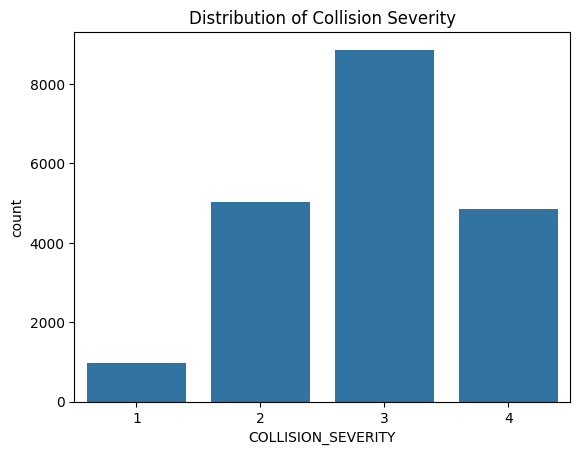

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

# Class Imbalance Bar Graph where # 1 = Fatal , 2 = Severe Injury , 3 = Visible Injury , 4 = Complaint of Pain

sns.countplot(x='COLLISION_SEVERITY', data=model_df)
plt.title("Distribution of Collision Severity")
plt.show()

It is easily seen where Fatal Accidents are far less creating a Class Imbalance in Severity Modeling

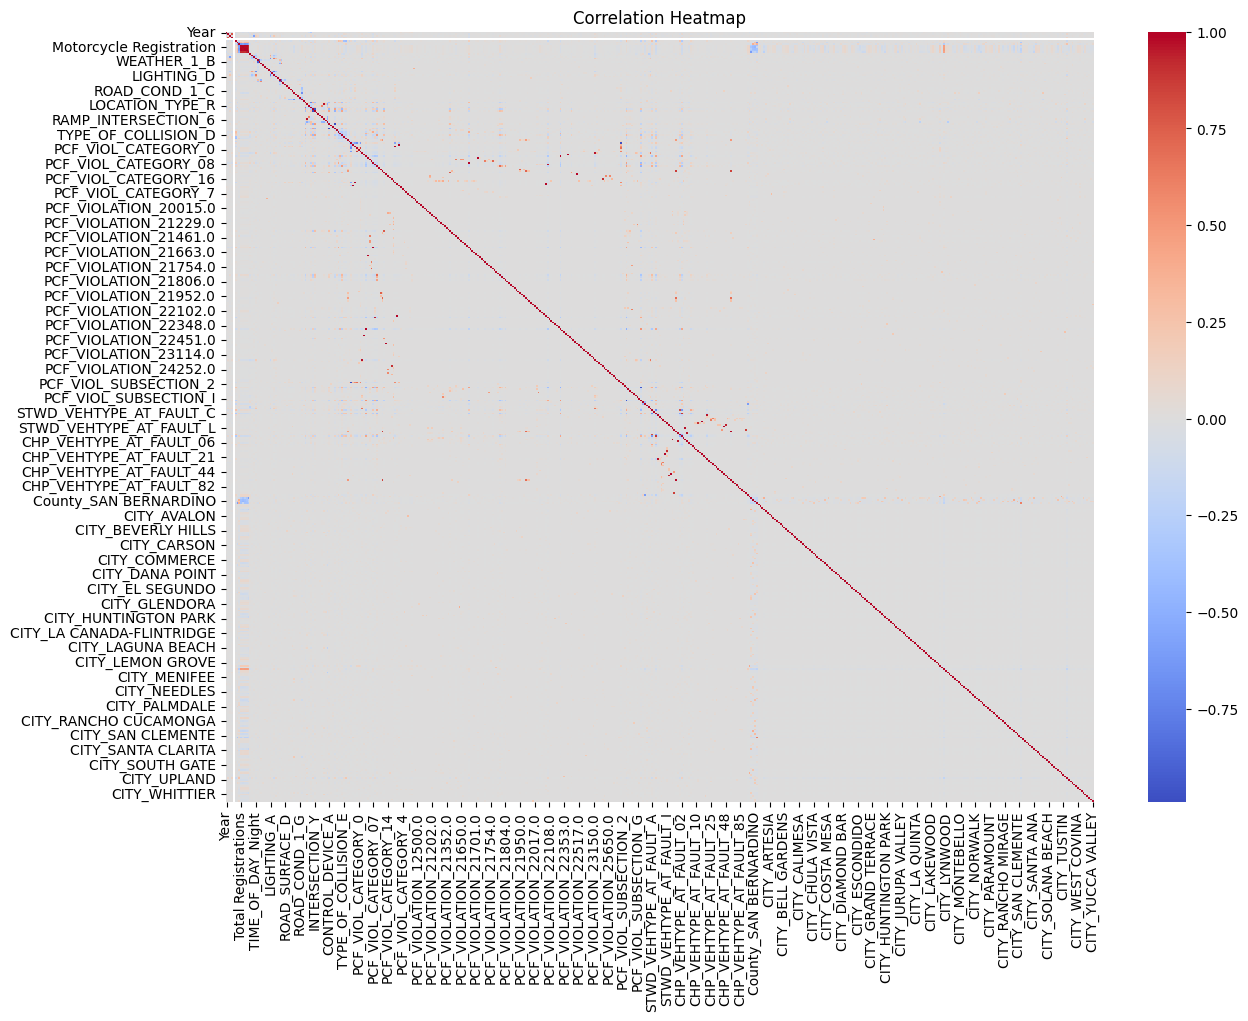

In [50]:
# Corrrelation Heatmap

plt.figure(figsize=(14,10))
sns.heatmap(df_encoded.corr(), cmap='coolwarm', center=0)
plt.title("Correlation Heatmap")
plt.show()

In [51]:
# Show Correlation Table By Making Dataframe

corr_table = (
    df_encoded.corr()['COLLISION_SEVERITY']
    .drop('COLLISION_SEVERITY')
    .sort_values(ascending=False)
)

corr_df = corr_table.reset_index()
corr_df.columns = ['Predictor', 'Correlation_with_Severity']
corr_df

,Predictor,Correlation_with_Severity
0,TYPE_OF_COLLISION_B,0.132095
1,PCF_VIOL_CATEGORY_07,0.110121
2,PCF_VIOLATION_21658.0,0.110117
3,LIGHTING_A,0.097096
4,HIT_AND_RUN_M,0.079874
...,...,...
467,PCF_VIOLATION_23152.0,-0.117759
468,PCF_VIOL_CATEGORY_01,-0.123446
469,ALCOHOL_INVOLVED_Y,-0.128273
470,TOW_AWAY_Y,-0.230291


In [52]:
# Display Top 20 Predictors

corr_df.head(20)

,Predictor,Correlation_with_Severity
0,TYPE_OF_COLLISION_B,0.132095
1,PCF_VIOL_CATEGORY_07,0.110121
2,PCF_VIOLATION_21658.0,0.110117
3,LIGHTING_A,0.097096
4,HIT_AND_RUN_M,0.079874
5,TIME_OF_DAY_Morning,0.061084
6,TYPE_OF_COLLISION_C,0.056127
7,STWD_VEHTYPE_AT_FAULT_A,0.056033
8,CHP_VEHTYPE_AT_FAULT_99,0.051516
9,CHP_VEHTYPE_AT_FAULT_01,0.045637


In [53]:
# Identifying Negativly Correlated Predictors

corr_df.tail(20)

,Predictor,Correlation_with_Severity
452,TYPE_OF_COLLISION_A,-0.053894
453,LONGITUDE,-0.058939
454,PCF_VIOLATION_21801.0,-0.063302
455,LIGHTING_C,-0.063661
456,PCF_VIOL_SUBSECTION_F,-0.066056
457,DAY_OF_WEEK,-0.070530
458,CITY_LOS ANGELES,-0.072665
459,IS_WEEKEND,-0.074185
460,LIGHTING_D,-0.078955
461,CITY_UNINCORPORATED,-0.079031


In [54]:
# Must Fix CHP_ROAD_TYPE since it is NaN and is a classification Code As Opposed to Numeric Quantity
# A case of mistaken Pandas Num/Cat variable

model_df['CHP_ROAD_TYPE'].dtype



dtype('int64')

In [57]:
import pandas as pd

# --- Ensure model_df exists ---
if 'model_df' not in globals():
    if 'df_merged' in globals() and 'predictors' in globals() and 'outcome' in globals():
        model_df = df_merged[predictors + [outcome]].copy()
    else:
        raise ValueError("df_merged, predictors, or outcome is not defined in the current session.")

In [61]:
# Convert to Categorical

model_df['CHP_ROAD_TYPE'] = model_df['CHP_ROAD_TYPE'].astype('category')

In [64]:
#Fill Missing Values to Unkown

model_df['CHP_ROAD_TYPE'] = model_df['CHP_ROAD_TYPE'].fillna('Unknown')


In [66]:
#Re-encode

df_encoded = pd.get_dummies(model_df, drop_first=True)

In [67]:
[col for col in df_encoded.columns if 'CHP_ROAD_TYPE' in col]

['CHP_ROAD_TYPE_Unknown']

In [68]:
model_df['CHP_ROAD_TYPE'].value_counts(dropna=False)

,count
CHP_ROAD_TYPE,
0,19721
Unknown,0


CHP_ROAD_TYPE has no variation therefore it cannot be used for prediction and must be dropped.

In [70]:
# Drop Column CHP_ROAD_TYPE

model_df = model_df.drop(columns=['CHP_ROAD_TYPE'])
df_encoded = df_encoded.drop(columns=['CHP_ROAD_TYPE_Unknown'], errors='ignore')

KeyError: "['CHP_ROAD_TYPE'] not found in axis"

In [71]:
# Checking Columns for removal

'CHP_ROAD_TYPE' in model_df.columns

False

In [74]:
# Identify any other ZERO Variance Predictors

# Identify zero-variance predictors
zero_var = [col for col in df_encoded.columns if df_encoded[col].nunique() <= 1]

print("Zero-variance predictors:", zero_var)

Zero-variance predictors: []


In [75]:
# Rebuildkng Clean Correlation Table

corr_table = (
    df_encoded.corr()['COLLISION_SEVERITY']
    .drop('COLLISION_SEVERITY')
    .sort_values(ascending=False)
)

corr_df = corr_table.reset_index()
corr_df.columns = ['Predictor', 'Correlation_with_Severity']
corr_df

,Predictor,Correlation_with_Severity
0,TYPE_OF_COLLISION_B,0.132095
1,PCF_VIOL_CATEGORY_07,0.110121
2,PCF_VIOLATION_21658.0,0.110117
3,LIGHTING_A,0.097096
4,HIT_AND_RUN_M,0.079874
...,...,...
466,TIME_OF_DAY_Night,-0.117032
467,PCF_VIOLATION_23152.0,-0.117759
468,PCF_VIOL_CATEGORY_01,-0.123446
469,ALCOHOL_INVOLVED_Y,-0.128273


In [76]:
# Meaningful Predictors (Cleaned)

corr_df[abs(corr_df['Correlation_with_Severity']) > 0.05]

,Predictor,Correlation_with_Severity
0,TYPE_OF_COLLISION_B,0.132095
1,PCF_VIOL_CATEGORY_07,0.110121
2,PCF_VIOLATION_21658.0,0.110117
3,LIGHTING_A,0.097096
4,HIT_AND_RUN_M,0.079874
5,TIME_OF_DAY_Morning,0.061084
6,TYPE_OF_COLLISION_C,0.056127
7,STWD_VEHTYPE_AT_FAULT_A,0.056033
8,CHP_VEHTYPE_AT_FAULT_99,0.051516
452,TYPE_OF_COLLISION_A,-0.053894


The correlation structure produced reflects a coherent pattern of severity‑related mechanisms that aligns well with established motorcycle crash‑injury research. Several predictors demonstrated meaningful positive associations with injury severity, indicating that these conditions or behaviors tend to occur more frequently in higher‑severity crashes. The strongest of these were collision‑configuration variables such as **TYPE_OF_COLLISION_B** and **TYPE_OF_COLLISION_C**, which typically represent angular or head‑on impact geometries. These crash types are known to generate higher kinetic energy transfer and expose motorcyclists to more direct impact forces, which explains their elevated correlation with severe outcomes. Behavioral risk factors also emerged prominently: **PCF_VIOL_CATEGORY_07** and **PCF_VIOLATION_21658.0**—categories often associated with improper turning, unsafe lane changes, or other hazardous maneuvers—showed strong positive associations with severity. These findings reinforce the role of rider or driver decision‑making in shaping crash energy and injury potential. Environmental visibility also contributed meaningfully, with **LIGHTING_A** indicating that low‑visibility conditions are disproportionately represented in severe crashes, consistent with literature documenting reduced hazard detection and increased reaction times in dark environments.

Several predictors exhibited negative correlations with severity, reflecting conditions more common in lower‑severity or property‑damage‑only crashes. The strongest of these was **TOW_AWAY_Y**, which is expected: tow‑away designations are typically assigned to crashes involving vehicle disablement rather than severe injury, and thus appear more frequently in low‑severity events. Additional negative associations were observed for specific PCF categories such as **PCF_VIOL_CATEGORY_01** and **PCF_VIOLATION_23152.0**, suggesting that some violation types correspond to lower‑energy crash scenarios. Lighting categories such as **LIGHTING_C** and **LIGHTING_D**, which generally represent daylight or well‑lit conditions, also showed negative correlations, consistent with the protective effect of improved visibility. Although **ALCOHOL_INVOLVED_Y** displayed a negative correlation, this pattern should not be interpreted substantively; alcohol involvement in SWITRS is known to suffer from structured missingness and under‑reporting, particularly in severe crashes, and the observed correlation likely reflects reporting artifacts rather than a true inverse relationship.

Taken together, the correlation profile indicates that the most influential severity‑related domains in this dataset are collision mechanics, hazardous behavioral violations, and environmental visibility. These findings align closely with established crash‑severity literature and provide a coherent empirical foundation for subsequent modeling.
